In [ ]:
# @title Setting up GridWorld Environment {"display-mode":"form"}


import numpy as np
from typing import Tuple, Callable, List
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# ---------------------------------------------------------------------
# Conventions (single source of truth)
# Position: numpy array [x, y] where x is column (0..cols-1), y is row (0..rows-1)
# Image array convention for ML: PyTorch-style (C, H, W) with dtype float32.
# Action indexing: 0=up (y-1), 1=down (y+1), 2=left (x-1), 3=right (x+1).
# preds_actions tensor shape (rows, cols, actions) == (H, W, A).
# ---------------------------------------------------------------------

Position = np.ndarray               # [x, y] as integers
State = Tuple[Position, Position]   # (agent_pos, goal_pos)
Action = int
Transition = Tuple[State, Action, State]
ValueArray = np.ndarray
Reward = Callable[[Transition], float]
Policy = np.ndarray
Trajectory = List[Tuple[State, Action]]

# ---------------------------------------------------------------------
# Deterministic gridworld
# ---------------------------------------------------------------------
class DeterministicGridWorld:
    def __init__(self, rows: int = 5, cols: int = 5, start: Tuple[int,int] = (0,0), goal: Tuple[int,int] = (4,4)):
        self.rows = int(rows)
        self.cols = int(cols)
        self.num_positions = self.rows * self.cols
        self.num_states = self.num_positions ** 2
        self.num_actions = 4
        # action vectors in [dx, dy] with the canonical ordering documented above
        self._actions = [np.array([0, -1], dtype=int),  # up
                         np.array([0,  1], dtype=int),  # down
                         np.array([-1, 0], dtype=int),  # left
                         np.array([1,  0], dtype=int)]  # right

        # stored as integer numpy arrays [x, y]
        self.start_coord = np.array(start, dtype=int)
        self.goal_coord = np.array(goal, dtype=int)

    # coordinate <-> index helpers (coord = [x, y])
    def coord_to_idx(self, coord: Position) -> int:
        x, y = int(coord[0]), int(coord[1])
        return int(x + y * self.cols)

    def idx_to_coord(self, idx: int) -> Position:
        x = int(idx % self.cols)
        y = int(idx // self.cols)
        return np.array([x, y], dtype=int)

    # state <-> index helpers (state = (agent_pos, star_pos))
    def state_to_idx(self, state: State) -> int:
        agent_pos, star_pos = state
        agent_idx = self.coord_to_idx(agent_pos)
        star_idx  = self.coord_to_idx(star_pos)
        return int(agent_idx + star_idx * self.num_positions)

    def idx_to_state(self, idx: int) -> State:
        agent_idx = int(idx % self.num_positions)
        star_idx  = int(idx // self.num_positions)
        return self.idx_to_coord(agent_idx), self.idx_to_coord(star_idx)

    # apply an action to a coordinate, clipped by grid bounds
    def next_coord(self, pos: Position, a: Action) -> Position:
        if a < 0 or a >= self.num_actions:
            raise ValueError("Invalid action")
        new = pos + self._actions[a]
        new_clipped = np.clip(new, [0, 0], [self.cols - 1, self.rows - 1])
        return new_clipped.astype(int)

    # next state (star unchanged)
    def next_state(self, s1: State, a: Action) -> State:
        pos, star = s1
        new_pos = self.next_coord(pos, a)
        return (new_pos, star)

    def next_state_from_idx(self, s1_idx: int, a: Action) -> int:
        s = self.idx_to_state(s1_idx)
        ns = self.next_state(s, a)
        return self.state_to_idx(ns)

    # enumerate all possible (agent_pos, star_pos) pairs
    def enumerate_states(self):
        for star_idx in range(self.num_positions):
            star = self.idx_to_coord(star_idx)
            for agent_idx in range(self.num_positions):
                agent = self.idx_to_coord(agent_idx)
                yield (agent, star)

# ---------------------------------------------------------------------
# Policies & rewards (small, explicit, and consistent)
# ---------------------------------------------------------------------
def uniform_policy(env: DeterministicGridWorld) -> Policy:
    return np.ones((env.num_states, env.num_actions), dtype=float) / float(env.num_actions)

def make_random_policy(env: DeterministicGridWorld, seed: int | None = None) -> Policy:
    rng = np.random.default_rng(seed)
    policy = np.zeros((env.num_states, env.num_actions), dtype=float)
    for s_idx in range(env.num_states):
        a = rng.integers(0, env.num_actions)
        policy[s_idx, a] = 1.0
    return policy

def star_reward(env: DeterministicGridWorld) -> Reward:
    # reward 1.0 when agent position equals star (goal)
    def r(transition: Transition) -> float:
        _, _, s2 = transition
        agent_pos, star_pos = s2
        return float((agent_pos == star_pos).all())
    return r

def corner_reward(env: DeterministicGridWorld) -> Reward:
    corner = np.array([env.cols - 1, env.rows - 1], dtype=int)
    def r(transition: Transition) -> float:
        _, _, s2 = transition
        agent_pos, _ = s2
        return float((agent_pos == corner).all())
    return r

def inverse_reward(reward: Reward) -> Reward:
    return lambda t: -reward(t)

# ---------------------------------------------------------------------
# Trajectory sampling (with small optional randomization)
# ---------------------------------------------------------------------
def sample_trajectory(env: DeterministicGridWorld, length: int, policy: Policy, seed: int | None = None,
                      randomize_start: bool = False, randomize_goal: bool = False) -> Trajectory:
    rng = np.random.default_rng(seed)
    start = env.start_coord.copy()
    goal = env.goal_coord.copy()
    if randomize_start:
        start = env.idx_to_coord(rng.integers(0, env.num_positions))
    if randomize_goal:
        goal = env.idx_to_coord(rng.integers(0, env.num_positions))
    state = (start, goal)
    traj: Trajectory = []
    for _ in range(length):
        s_idx = env.state_to_idx(state)
        a = int(rng.choice(env.num_actions, p=policy[s_idx]))
        traj.append((state, a))
        state = env.next_state(state, a)
    return traj

# ---------------------------------------------------------------------
# ML renderer: numeric image arrays for a state
# Returns image in PyTorch-friendly shape (C, H, W), dtype float32.
# Channel semantics (default):
#   ch0 = agent one-hot, ch1 = static goal/star one-hot, ch2 = empty (reserved) or obstacles
# ---------------------------------------------------------------------

#<change>
def render_state_as_image(env: DeterministicGridWorld, state: State,
                          channels: int = 3, dtype=np.float32) -> np.ndarray:
    agent_pos, star_pos = state
    H, W = env.rows, env.cols

    ch_star  = np.zeros((H, W), dtype=dtype)  # star -> channel 0
    ch_agent = np.zeros((H, W), dtype=dtype)  # agent -> channel 1
    ch_misc  = np.zeros((H, W), dtype=dtype)

    ax, ay = int(agent_pos[0]), int(agent_pos[1])
    gx, gy = int(star_pos[0]), int(star_pos[1])
    ch_star[gy, gx] = 1.0
    ch_agent[ay, ax] = 1.0

    img = np.stack([ch_star, ch_agent, ch_misc], axis=0).astype(dtype)
    #</change>

    if channels != 3:
        # simple trimming or padding if user requests different channel count
        if channels < 3:
            img = img[:channels]
        else:
            pad = np.zeros((channels - 3, H, W), dtype=dtype)
            img = np.concatenate([img, pad], axis=0)
    return img

# ---------------------------------------------------------------------
# Visualization: quadrant action heatmap expects preds_actions shape (rows, cols, A)
# ---------------------------------------------------------------------
def plot_quadrant_action_heatmap(preds_actions: np.ndarray, star_coords: Tuple[int,int] | None = None,
                                 title: str | None = None, cmap: str = 'viridis',
                                 vmin: float | None = None, vmax: float | None = None,
                                 show_grid: bool = True, cell_edge_color: str = 'k') -> None:
    rows, cols, A = preds_actions.shape
    assert A == 4, "preds_actions must have shape (rows, cols, 4)"

    if vmin is None:
        vmin = float(preds_actions.min())
    if vmax is None:
        vmax = float(preds_actions.max())
    norm = Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.get_cmap(cmap)

    fig, ax = plt.subplots(figsize=(cols + 1, rows + 1))
    ax.set_xlim(0, cols)
    ax.set_ylim(0, rows)
    ax.set_aspect('equal')

    for r in range(rows):
        for c in range(cols):
            cx = c + 0.5
            cy = r + 0.5
            bl = (c, r)
            br = (c + 1, r)
            tl = (c, r + 1)
            tr = (c + 1, r + 1)
            center = (cx, cy)

            tri_up    = [tl, tr, center]    # action 0 (up)
            tri_down  = [br, bl, center]    # action 1 (down)
            tri_left  = [bl, tl, center]    # action 2 (left)
            tri_right = [tr, br, center]    # action 3 (right)
            triangles = [tri_up, tri_down, tri_left, tri_right]

            for a in range(4):
                val = float(preds_actions[r, c, a])
                color = cmap(norm(val))
                poly = Polygon(triangles[a], closed=True,
                               facecolor=color, edgecolor=cell_edge_color, linewidth=0.3)
                ax.add_patch(poly)

    # grid lines
    if show_grid:
        for x in range(cols + 1):
            ax.plot([x, x], [0, rows], color='black', linewidth=0.6, alpha=0.6)
        for y in range(rows + 1):
            ax.plot([0, cols], [y, y], color='black', linewidth=0.6, alpha=0.6)

    # star markers (star_coords expected as (x, y) following Position convention)
    if star_coords is not None:
        sx, sy = star_coords
        ax.scatter([sx + 0.5], [sy + 0.5], s=200, marker='*',
                   edgecolor='white', facecolor='yellow', linewidth=1.0, zorder=5)

    # colorbar
    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array(preds_actions)
    cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Value')

    ax.set_xticks(np.arange(0.5, cols, 1))
    ax.set_yticks(np.arange(0.5, rows, 1))
    ax.set_xticklabels(np.arange(0, cols))
    ax.set_yticklabels(np.arange(0, rows))

    ax.set_xlabel('X coordinate (col)', fontsize=12)
    ax.set_ylabel('Y coordinate (row)', fontsize=12)
    if title is not None:
        ax.set_title(title, fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------------------
# Utility: visualize reward function over state-action pairs for fixed star pos
# ---------------------------------------------------------------------
def visualize_reward_quadrant(env: DeterministicGridWorld, reward: Reward,
                              star: Position | None = None, title: str = "Reward Map") -> None:
    if star is None:
        star = env.goal_coord
    rows, cols, A = env.rows, env.cols, env.num_actions
    preds_actions = np.zeros((rows, cols, A), dtype=np.float32)

    for r in range(rows):
        for c in range(cols):
            agent_pos = np.array([c, r], dtype=int)  # [x, y]
            s1 = (agent_pos, star)
            for a in range(A):
                s2 = env.next_state(s1, a)
                preds_actions[r, c, a] = float(reward((s1, a, s2)))

    plot_quadrant_action_heatmap(preds_actions, star_coords=(int(star[0]), int(star[1])), title=title, vmin=-1, vmax=1)

In [ ]:
# @title STARC (modified for CNN) {"display-mode":"form"}


# STARC utilities adapted for CNN -> scalar-per-state predictions (PyTorch)
# Requires: numpy as np, torch

import numpy as np
import torch
import torch.nn.functional as F
from typing import Callable, List, Tuple, Optional

# ---------------------------
# NumPy utilities (for checks / offline use)
# ---------------------------
def build_transition_matrix_np(env) -> np.ndarray:
    """P_np: shape (S, A, S) with P[s,a,s'] = 1 for deterministic transitions."""
    S, A = env.num_states, env.num_actions
    P = np.zeros((S, A, S), dtype=np.float32)
    for s in range(S):
        for a in range(A):
            s_next = env.next_state_from_idx(s, a)
            P[s, a, s_next] = 1.0
    return P

def build_successor_representation_np(P: np.ndarray, policy: np.ndarray, gamma: float = 0.9) -> np.ndarray:
    P_policy = np.einsum("saj,sa->sj", P, policy)  # (S,S)
    F = np.linalg.inv(np.eye(P_policy.shape[0], dtype=np.float32) - gamma * P_policy + 1e-8 * np.eye(P_policy.shape[0]))
    return F

def canonicalise_reward_np(F: np.ndarray, P: np.ndarray, R: np.ndarray, policy: np.ndarray, gamma: float = 0.9) -> np.ndarray:
    S, A = R.shape
    expected_r = (R * policy).sum(axis=1)         # (S,)
    V = F @ expected_r                             # (S,)
    PV = np.einsum("saj,j->sa", P, V)              # (S,A)
    C = R - V.reshape(S, 1) + gamma * PV
    return C

def s_norm_np(Rc: np.ndarray) -> np.ndarray:
    norm = np.linalg.norm(Rc)
    if norm == 0:
        return Rc
    return Rc / norm
#</change>

def starc_distance_np(env, policy: np.ndarray, r1_state: np.ndarray, r2_state: np.ndarray, gamma: float = 0.9) -> float:
    """
    r1_state, r2_state: arrays of shape (S,) or (S,1) giving r(s) for each canonical state.
    Computes STARc distance (L2 on canonicalised & normalized R matrices).
    """
    r1_state = r1_state.reshape(-1)
    r2_state = r2_state.reshape(-1)
    P = build_transition_matrix_np(env)               # (S,A,S)
    F = build_successor_representation_np(P, policy, gamma)  # (S,S)
    S, A, _ = P.shape

    # Build state-action reward matrices by mapping r(s') onto R[s,a] = r(next_state)
    R1 = np.zeros((S, A), dtype=np.float32)
    R2 = np.zeros((S, A), dtype=np.float32)
    for s in range(S):
        for a in range(A):
            ns = env.next_state_from_idx(s, a)
            R1[s, a] = float(r1_state[ns])
            R2[s, a] = float(r2_state[ns])

    C1 = canonicalise_reward_np(F, P, R1, policy, gamma)
    C2 = canonicalise_reward_np(F, P, R2, policy, gamma)
    return float(np.linalg.norm(s_norm_np(C1) - s_norm_np(C2)))


# ---------------------------
# PyTorch (differentiable) implementations for training integration
# ---------------------------
def build_transition_matrix_torch(env, device: Optional[torch.device] = None) -> torch.Tensor:
    """Returns P_t: (S, A, S) float tensor on device (or cpu if device None)."""
    device = torch.device("cpu") if device is None else device
    S, A = env.num_states, env.num_actions
    P = torch.zeros((S, A, S), dtype=torch.float32, device=device)
    for s in range(S):
        for a in range(A):
            ns = env.next_state_from_idx(s, a)
            P[s, a, ns] = 1.0
    return P

def build_successor_representation_torch(P_t: torch.Tensor, policy_t: torch.Tensor, gamma: float = 0.9) -> torch.Tensor:
    # P_t: (S,A,S), policy_t: (S,A)
    P_policy = torch.einsum("saj,sa->sj", P_t, policy_t)  # (S,S)
    I = torch.eye(P_policy.size(0), dtype=P_t.dtype, device=P_t.device)
    F = torch.inverse(I - gamma * P_policy)
    return F

def canonicalise_reward_torch(F_t: torch.Tensor, P_t: torch.Tensor, R_t: torch.Tensor, policy_t: torch.Tensor, gamma: float = 0.9) -> torch.Tensor:
    S, A = R_t.shape
    expected_r = (R_t * policy_t).sum(dim=1)   # (S,)
    V = F_t.matmul(expected_r)                 # (S,)
    # PV[s,a] = sum_{s'} P[s,a,s'] * V[s']
    PV = torch.einsum("saj,j->sa", P_t, V)     # (S,A)
    C_t = R_t - V.view(S, 1) + gamma * PV
    return C_t

def s_norm_torch(Rc_t: torch.Tensor) -> torch.Tensor:
    norm = torch.norm(Rc_t)
    if norm == 0:
        return Rc_t
    return Rc_t / norm

# ---------------------------
# Helper: turn state-value vector r_state (S,) into state-action R (S,A)
# ---------------------------
def state_values_to_state_action_rewards_from_next_state_indices(r_state_t: torch.Tensor, next_state_idx: torch.Tensor) -> torch.Tensor:
    """
    r_state_t: (S,) or (S,1) tensor giving predicted reward for each canonical state (r(s)).
    next_state_idx: (S,A) long tensor where next_state_idx[s,a] = idx of s' = next_state(s,a)
    Returns R_t: (S,A) where R_t[s,a] = r_state_t[next_state_idx[s,a]]
    """
    # Ensure r_state is shape (S,)
    r_flat = r_state_t.reshape(-1)  # (S,)
    # index gather: next_state_idx shape (S,A), result (S,A)
    R_t = r_flat[next_state_idx]    # advanced indexing -> (S,A)
    return R_t

# ---------------------------
# Ensemble loss builder
# ---------------------------
def ensemble_starc_loss_builder(env,
                                policy_np: np.ndarray,
                                gamma: float = 0.9,
                                device: Optional[torch.device] = None,
                                include_frozen_models: Optional[List[torch.nn.Module]] = None):
    """
    Returns a loss function suitable for use inside training that computes average pairwise STARc
    distance (L2 on canonicalised & normalized R matrices) between an active set of models and any
    frozen models.

    Usage:
      loss_fn = ensemble_starc_loss_builder(env, policy_np, gamma, device, frozen_models)
      # inside training step, you have a list `active_models` whose predictions over the full-domain
      # images you compute once per epoch:
      r_preds = [model(images_full_t).reshape(S,) for model in active_models]  # each is (S,)
      loss_val, trackers = loss_fn(r_preds)   # loss_val is a scalar torch tensor, trackers useful for logging

    Note: `images_full` and `state ordering` must match env.idx_to_state ordering.
    """
    device = torch.device("cpu") if device is None else device
    S, A = env.num_states, env.num_actions

    # Precompute next_state_idx array (S,A) with indices of s' for each (s,a)
    next_state_idx = np.zeros((S, A), dtype=np.int64)
    for s in range(S):
        for a in range(A):
            next_state_idx[s, a] = env.next_state_from_idx(s, a)
    next_state_idx_t = torch.from_numpy(next_state_idx).long().to(device)  # (S,A)

    # Precompute P and F (torch)
    P_t = build_transition_matrix_torch(env, device=device)  # (S,A,S)
    policy_t = torch.from_numpy(policy_np).float().to(device) # (S,A)
    F_t = build_successor_representation_torch(P_t, policy_t, gamma)  # (S,S)

    # Precompute canonicalised & normalized frozen models if any
    frozen_canonicalised = []
    if include_frozen_models:
        # For frozen models we expect you to provide predicted r_state_full tensor (S,) or model that can be run on images_full
        # Here we only support passing in models that we will forward outside this builder (see usage note).
        raise NotImplementedError("Passing frozen model objects is not implemented here. Instead pass their r_state_full tensors to the loss function.")

    def loss_fn(r_state_preds: List[torch.Tensor]):
        """
        r_state_preds: list of torch tensors, each shape (S,) or (S,1); these are predictions r(s) for every canonical state.
        Returns: (loss_tensor, trackers_dict)
        """
        n = len(r_state_preds)
        # Convert each r_state to R (S,A)
        R_list = []
        for r in r_state_preds:
            r = r.reshape(-1)  # (S,)
            R = state_values_to_state_action_rewards_from_next_state_indices(r, next_state_idx_t)  # (S,A)
            R_list.append(R)

        # canonicalise each R -> C (S,A) and normalize
        C_list = []
        for R in R_list:
            C = canonicalise_reward_torch(F_t, P_t, R, policy_t, gamma)  # (S,A)
            Cn = s_norm_torch(C)
            C_list.append(Cn.reshape(-1))  # flatten to vector (S*A,)

        # pairwise distances (upper triangle)
        total_dist = torch.tensor(0.0, device=device)
        max_dist = torch.tensor(0.0, device=device)
        count = 0
        for i in range(n):
            for j in range(i+1, n):
                dist = torch.norm(C_list[i] - C_list[j])
                total_dist += dist
                max_dist = torch.max(max_dist, dist)
                count += 1

        if count == 0:
            avg_dist = torch.tensor(0.0, device=device)
        else:
            avg_dist = total_dist / float(count)

        trackers = {"avg_dist": float(avg_dist.detach().cpu().item()), "max_dist": float(max_dist.detach().cpu().item())}
        return avg_dist, trackers

    # Attach some useful internals for debugging
    loss_fn._P_t = P_t
    loss_fn._F_t = F_t
    loss_fn._next_state_idx = next_state_idx_t
    loss_fn._policy = policy_t
    return loss_fn

In [ ]:
# @title State space and images stuff - different from Cath's {"display-mode":"form"}

# Output file: "grid_full_domain.npz" containing:
#   images_full: (num_states, C, H, W) float32
#   true_rewards_full: (num_states, 1) float32
#   state_index_map: (num_states, 2, 2) int32  where entry [idx,0] = agent_pos [x,y], [idx,1] = star_pos [x,y]
#   chan_mean, chan_std: per-channel normalization stats (C,)
#   meta: dict with rows, cols, channels, num_states
#
# Note: This cell intentionally uses env.idx_to_state(idx) to ensure the canonical mapping is exactly
# the same one used by DeterministicGridWorld.state_to_idx / idx_to_state.

import numpy as np
import os
from tqdm import trange

OUT_PATH = "grid_full_domain.npz"

# --- Sanity: require env and a renderer ---
if "DeterministicGridWorld" not in globals():
    raise RuntimeError("DeterministicGridWorld not found in the notebook. Run the gridworld cell first.")

# instantiate env with the same params you used elsewhere (adjust if needed)
env = DeterministicGridWorld(rows=7, cols=7, start=(0,0), goal=(5,5))

# check for renderer name used earlier; prefer render_state_as_image (returns (C,H,W))
use_render_fn = None
if "render_state_as_image" in globals():
    use_render_fn = "render_state_as_image"
elif "make_grid_image" in globals():
    use_render_fn = "make_grid_image"
else:
    raise RuntimeError("No renderer found. Define `render_state_as_image(env, state)` or `make_grid_image(agent_pos, star_pos)` and re-run the gridworld cell.")

num_states = env.num_states
C = 3
H, W = env.rows, env.cols

images_full = np.zeros((num_states, C, H, W), dtype=np.float32)
true_rewards_full = np.zeros((num_states, 1), dtype=np.float32)
state_index_map = np.zeros((num_states, 2, 2), dtype=np.int32)  # [idx, 0]=agent[x,y], [idx,1]=star[x,y]

for idx in trange(num_states, desc="Rendering full domain"):
    # reconstruct canonical state
    agent_pos, star_pos = env.idx_to_state(idx)  # both are np.array([x,y])
    agent_tuple = (int(agent_pos[0]), int(agent_pos[1]))
    star_tuple = (int(star_pos[0]), int(star_pos[1]))
    state_index_map[idx, 0, :] = [agent_tuple[0], agent_tuple[1]]
    state_index_map[idx, 1, :] = [star_tuple[0], star_tuple[1]]

    # render image using whichever renderer is present
    if use_render_fn == "render_state_as_image":
        # render_state_as_image(env, state) -> np.ndarray (C,H,W)
        img = render_state_as_image(env, (agent_pos, star_pos))
        images_full[idx] = img.astype(np.float32)
        # compute reward: by default, 1.0 when agent==star, else 0.0
        true_rewards_full[idx, 0] = 1.0 if (agent_tuple == star_tuple) else 0.0
    else:
        # make_grid_image(agent_pos, star_pos) -> (img, reward) in older scripts
        img, r = make_grid_image(agent_pos, star_pos)
        images_full[idx] = img.astype(np.float32)
        true_rewards_full[idx, 0] = float(r)

# channel normalization stats (computed on full domain)
chan_mean = images_full.mean(axis=(0,2,3))   # shape (C,)
chan_std  = images_full.std(axis=(0,2,3)) + 1e-8

meta = {
    "rows": H,
    "cols": W,
    "channels": C,
    "num_states": int(num_states),
    "state_indexing": "env.idx_to_state(idx) -> (agent_pos, star_pos)"
}

# Save to npz
np.savez_compressed(OUT_PATH,
                    images_full=images_full,
                    true_rewards_full=true_rewards_full,
                    state_index_map=state_index_map,
                    chan_mean=chan_mean,
                    chan_std=chan_std,
                    meta=meta)

print(f"Saved full-domain dataset to {OUT_PATH}")
print("images_full shape:", images_full.shape)
print("true_rewards_full shape:", true_rewards_full.shape)
print("state_index_map shape:", state_index_map.shape)
print("chan_mean:", chan_mean)
print("chan_std:", chan_std)

Rendering full domain: 100%|██████████| 2401/2401 [00:00<00:00, 62838.66it/s]

Saved full-domain dataset to grid_full_domain.npz
images_full shape: (2401, 3, 7, 7)
true_rewards_full shape: (2401, 1)
state_index_map shape: (2401, 2, 2)
chan_mean: [0.02040816 0.02040816 0.        ]
chan_std: [1.4139201e-01 1.4139201e-01 9.9999999e-09]


In [ ]:
# @title CNN {"display-mode":"form"}


# Cleaned training script for gridworld -> scalar reward regression
# - Outputs a single scalar per image (regression)
# - Uses MSE loss
# - Keeps only essential dataset / model / training logic
# - Small hook `compute_full_domain_metric` where you can call STARC later

import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from typing import Tuple
from tqdm import trange

# ------------------------
# Config
# ------------------------
H = W = 7
CHANNELS = 3
STAR_POS = (5, 5)
AGENT_ALLOWED = list(range(1, 7))
N_POS = 2000
N_NEG = 2000
BATCH_SIZE = 64
EPOCHS = 25
LR = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42
ALPHA = 0.0  # placeholder: weight for -alpha * STARC (0.0 means no STARC in loss)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ------------------------
# Simple image generator (kept from your original)
# ------------------------
def make_grid_image(agent_pos: Tuple[int,int], star_pos: Tuple[int,int] = STAR_POS):
    """
    Channel order: (R, G, B)
    R: star, G: agent, B: border
    Returns (img: np.float32 (3,H,W), reward: float scalar 0.0/1.0)
    """
    r_agent, c_agent = agent_pos
    img = np.zeros((CHANNELS, H, W), dtype=np.float32)

    # Border -> BLUE channel (index 2)
    img[2, 0, :] = 1.0
    img[2, -1, :] = 1.0
    img[2, :, 0] = 1.0
    img[2, :, -1] = 1.0

    # Star -> RED channel (index 0)
    r_star, c_star = star_pos
    img[0, r_star, c_star] = 1.0

    # Agent -> GREEN channel (index 1)
    img[1, r_agent, c_agent] = 1.0

    reward = 1.0 if (r_agent, c_agent) == (r_star, c_star) else 0.0
    return img, reward

# ------------------------
# Balanced dataset generator (returns numpy arrays)
# ------------------------
def generate_balanced_dataset(n_pos=N_POS, n_neg=N_NEG):
    X = []
    y = []
    # positives: agent located at STAR_POS
    for _ in range(n_pos):
        img, r = make_grid_image(agent_pos=STAR_POS, star_pos=STAR_POS)
        X.append(img)
        y.append(r)
    # negatives: agent anywhere in allowed_positions except STAR_POS
    allowed_positions = [(r, c) for r in AGENT_ALLOWED for c in AGENT_ALLOWED]
    allowed_positions = [p for p in allowed_positions if p != STAR_POS]
    for _ in range(n_neg):
        pos = random.choice(allowed_positions)
        img, r = make_grid_image(agent_pos=pos, star_pos=STAR_POS)
        X.append(img)
        y.append(r)
    X = np.stack(X).astype(np.float32)    # (N, C, H, W)
    y = np.array(y, dtype=np.float32).reshape(-1, 1)  # (N, 1) floats for regression
    # shuffle
    perm = np.random.permutation(len(X))
    return X[perm], y[perm]

# ------------------------
# Dataset wrapper
# ------------------------
class GridDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        img = torch.from_numpy(self.X[idx])            # float32 (C,H,W)
        label = torch.from_numpy(self.y[idx]).float() # float32 (1,)
        return img, label

# ------------------------
# Tiny regression CNN (single scalar output)
# - simplified, fewer channels/parameters kept small for fast experiments
# ------------------------
class CNN(nn.Module):
    def __init__(self, in_channels=3, hidden_channels=1):
        super().__init__()
        # small conv stack
        self.conv1 = nn.Conv2d(in_channels, hidden_channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(hidden_channels, hidden_channels, kernel_size=3, padding=1)
        self.pool = nn.AdaptiveAvgPool2d((3,3))
        flat = hidden_channels * 3 * 3
        self.fc1 = nn.Linear(flat, 64)
        self.fc_out = nn.Linear(64, 1)  # single scalar output

        # optional: simple initialization
        nn.init.kaiming_normal_(self.conv1.weight, nonlinearity='relu')
        nn.init.kaiming_normal_(self.conv2.weight, nonlinearity='relu')
        nn.init.xavier_uniform_(self.fc1.weight)
        nn.init.xavier_uniform_(self.fc_out.weight)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        out = self.fc_out(x)  # raw scalar (no activation)
        return out

# ------------------------
# Hook for full-domain metric (STARC) integration
# - This is a placeholder: later, compute r_pred_full by forwarding
#   your enumerated full-domain images through `model` and pass to STARC.
# ------------------------
def compute_full_domain_metric(model, images_full_np, true_rewards_full_np):
    """
    images_full_np: np.ndarray (num_states, C, H, W)
    true_rewards_full_np: np.ndarray (num_states, 1)
    Returns a dict with metric placeholders. Replace STARC implementation here.
    """
    model.eval()
    with torch.no_grad():
        imgs = torch.from_numpy(images_full_np).to(DEVICE)
        preds = model(imgs).cpu().numpy()  # (num_states, 1)
    # Placeholder: compute a simple L2 between predicted and true full reward vectors
    l2 = float(np.mean((preds - true_rewards_full_np)**2))
    # Replace the following with STARC(preds, true_rewards_full_np) when available
    return {"full_l2": l2, "starc": None}

# ------------------------
# Training loop (MSE regression)
# ------------------------
def train_one_epoch(model, loader, opt, criterion):
    model.train()
    total_loss = 0.0
    total = 0
    for imgs, labels in loader:
        imgs = imgs.to(DEVICE)
        labels = labels.to(DEVICE)
        opt.zero_grad()
        out = model(imgs)          # (B,1)
        mse = criterion(out, labels)
        # if you include STARC inside gradient, add -ALPHA * starc_term here (requires starc differentiable)
        loss = mse
        loss.backward()
        opt.step()
        total_loss += loss.item() * imgs.size(0)
        total += imgs.size(0)
    return total_loss / total

def eval_model(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total = 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            labels = labels.to(DEVICE)
            out = model(imgs)
            loss = criterion(out, labels)
            total_loss += loss.item() * imgs.size(0)
            total += imgs.size(0)
    return total_loss / total

# ------------------------
# Main runner
# ------------------------
def main():
    # Generate dataset
    X, y = generate_balanced_dataset()
    N = len(X)
    n_val = int(0.1 * N)
    n_train = N - n_val
    train_X, val_X = X[:n_train], X[n_train:]
    train_y, val_y = y[:n_train], y[n_train:]
    train_ds = GridDataset(train_X, train_y)
    val_ds = GridDataset(val_X, val_y)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

    model = CNN(in_channels=CHANNELS).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = nn.MSELoss()

    print(f"Training (regression) on {len(train_ds)} samples, validating on {len(val_ds)} samples, device={DEVICE}")
    for epoch in range(1, EPOCHS + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss = eval_model(model, val_loader, criterion)
        print(f"Epoch {epoch:02d}: train_mse={train_loss:.6f} | val_mse={val_loss:.6f}")

        # Example place to compute full-domain metric each epoch (if you have images_full / true_full)
        # if you saved images_full.npy and true_rewards_full.npy, load them and call compute_full_domain_metric(...)
        # metrics = compute_full_domain_metric(model, images_full_np, true_rewards_full_np)
        # print(f"  full_l2={metrics['full_l2']:.6f} starc={metrics['starc']}")

    # Save final model
    torch.save({'model_state_dict': model.state_dict()}, "tinycnn_reg.pth")
    print("Saved model to tinycnn_reg.pth")

if __name__ == "__main__":
    main()

Training (regression) on 3600 samples, validating on 400 samples, device=cuda
Epoch 01: train_mse=0.335973 | val_mse=0.242223
Epoch 02: train_mse=0.231310 | val_mse=0.222250
Epoch 03: train_mse=0.210386 | val_mse=0.192347
Epoch 04: train_mse=0.168718 | val_mse=0.136610
Epoch 05: train_mse=0.099614 | val_mse=0.062877
Epoch 06: train_mse=0.035923 | val_mse=0.016844
Epoch 07: train_mse=0.011631 | val_mse=0.008122
Epoch 08: train_mse=0.006378 | val_mse=0.004620
Epoch 09: train_mse=0.004168 | val_mse=0.003144
Epoch 10: train_mse=0.003130 | val_mse=0.002384
Epoch 11: train_mse=0.002673 | val_mse=0.002051
Epoch 12: train_mse=0.002343 | val_mse=0.001663
Epoch 13: train_mse=0.001852 | val_mse=0.001358
Epoch 14: train_mse=0.001553 | val_mse=0.001201
Epoch 15: train_mse=0.001350 | val_mse=0.001065
Epoch 16: train_mse=0.001184 | val_mse=0.000956
Epoch 17: train_mse=0.001056 | val_mse=0.000859
Epoch 18: train_mse=0.000942 | val_mse=0.000786
Epoch 19: train_mse=0.000860 | val_mse=0.000732
Epoch 20: 

In [ ]:
# === Cell: train frozen model main ===
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

def train_frozen_model(
    # dataset / training params
    n_pos: int = 2000,
    n_neg: int = 2000,
    batch_size: int = 128,
    val_frac: float = 0.1,
    shuffle: bool = True,
    # model / optimization params
    hidden_channels: int = 8,
    lr: float = 1e-3,
    epochs: int = 60,
    weight_decay: float = 0.0,
    # I/O
    ckpt_path: str = "frozen_model_classification.pth",
    save_full_domain: bool = True,
    device: torch.device | str = None,
    seed: int = 42
):
    """
    Train a frozen (reference) reward model (classification) on the fixed-star dataset.

    Assumes the notebook defines:
      - generate_balanced_fixed_star(n_pos, n_neg, shuffle=True)
      - GridDataset (Dataset wrapper)
      - TinyCNN(in_channels=..., hidden_channels=..., num_classes=2)
      - print_conv_kernels(model, label="...")
      - model_predict_full(model, images_full, device=..., batch_size=...)
      - build_full_domain() -> (images_full, true_r_full, state_index_map)
    """
    # device
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    else:
        device = torch.device(device)

    # reproducibility
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    print("Device:", device)
    print(f"Training frozen model (hidden_channels={hidden_channels})")

    # --- dataset generation (expects function from notebook) ---
    if "generate_balanced_fixed_star" not in globals():
        raise RuntimeError("generate_balanced_fixed_star not found in notebook. Define it before calling this function.")
    X, y = generate_balanced_fixed_star(n_pos=n_pos, n_neg=n_neg, shuffle=shuffle)
    N = len(X)
    n_val = max(1, int(val_frac * N))
    n_train = N - n_val
    print(f"Generated dataset: N={N} (train={n_train}, val={n_val})  pos={int((y==1).sum())} neg={int((y==0).sum())}")

    # split
    train_X, val_X = X[:n_train], X[n_train:]
    train_y, val_y = y[:n_train], y[n_train:]

    # dataset / loader (expects GridDataset in notebook)
    train_ds = GridDataset(train_X, train_y)
    val_ds = GridDataset(val_X, val_y)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    # --- model instantiation (expects TinyCNN class in notebook) ---
    if "TinyCNN" not in globals():
        raise RuntimeError("TinyCNN class not found in notebook. Define it before calling this function.")
    # infer input channels from data if possible
    in_ch = train_X.shape[1] if train_X.ndim >= 3 else 3
    model = TinyCNN(in_channels=int(in_ch), hidden_channels=hidden_channels, num_classes=2).to(device)

    # optimizer / criterion
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()

    # --- training loop ---
    for ep in range(1, epochs + 1):
        # train
        model.train()
        running_loss = 0.0
        running_correct = 0
        running_n = 0
        for imgs, labels in train_loader:
            imgs = imgs.to(device).float()
            labels = labels.to(device).long()
            opt.zero_grad()
            out = model(imgs)            # (B,2)
            loss = criterion(out, labels)
            loss.backward()
            opt.step()
            running_loss += float(loss.item()) * imgs.size(0)
            preds = out.argmax(dim=1)
            running_correct += (preds == labels).sum().item()
            running_n += imgs.size(0)
        train_loss = running_loss / running_n
        train_acc = running_correct / running_n

        # val
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_n = 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs = imgs.to(device).float()
                labels = labels.to(device).long()
                out = model(imgs)
                loss = criterion(out, labels)
                val_loss += float(loss.item()) * imgs.size(0)
                preds = out.argmax(dim=1)
                val_correct += (preds == labels).sum().item()
                val_n += imgs.size(0)
        val_loss = val_loss / val_n if val_n > 0 else float('nan')
        val_acc = val_correct / val_n if val_n > 0 else float('nan')

        # print every few epochs
        if ep == 1 or ep % 5 == 0 or ep == epochs:
            print(f"Epoch {ep:03d} | train_loss={train_loss:.4f} train_acc={train_acc:.4f} | val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    # --- save checkpoint ---
    torch.save({'model_state_dict': model.state_dict()}, ckpt_path)
    print("Saved checkpoint to", ckpt_path)

    # --- print conv kernels numerically if helper exists ---
    if "print_conv_kernels" in globals():
        print_conv_kernels(model, label="Frozen model (trained)")
    else:
        print("print_conv_kernels not found in notebook; skipping numeric kernel printout.")

    # --- quick unit checks on few canonical states if helper make_grid_image exists ---
    if "make_grid_image" in globals():
        def _single_pred(agent, star):
            img, _ = make_grid_image(agent, star)
            t = torch.from_numpy(img).unsqueeze(0).float().to(device)
            with torch.no_grad():
                out = model(t)
                p = torch.softmax(out, dim=1)[0,1].item()
            return p
        # pick the fixed star used by your dataset generator if available
        star_pos = globals().get("FIXED_STAR", None)
        if star_pos is None and "STAR_POS" in globals():
            star_pos = STAR_POS
        if star_pos is None:
            # fallback to (6,6) on 7x7
            star_pos = (6,6)
        some_other = (globals().get("AGENT_MIN", 1), globals().get("AGENT_MIN", 1))
        print("\nUnit checks (P(reward=1)):")
        print(" agent==star:", _single_pred(star_pos, star_pos))
        print(" agent!=star:", _single_pred(some_other, star_pos))
    else:
        print("make_grid_image not found; skipping unit state checks.")

    # --- optionally compute full-domain predictions and save them if build_full_domain & model_predict_full exist ---
    if save_full_domain:
        if "build_full_domain" in globals() and "model_predict_full" in globals():
            print("Building full-domain images and computing full-domain predictions...")
            images_full, true_r_full, state_index_map = build_full_domain()
            r_pred_full = model_predict_full(model, images_full, device=device, batch_size=256)
            np.savez_compressed(os.path.splitext(ckpt_path)[0] + "_full_domain.npz",
                                r_pred_full=r_pred_full,
                                true_r_full=true_r_full,
                                state_index_map=np.array(state_index_map))
            print("Saved full-domain predictions to", os.path.splitext(ckpt_path)[0] + "_full_domain.npz")
        else:
            print("Either build_full_domain or model_predict_full not found in notebook; skipping full-domain forward/save.")

    return model

# === Example invocation (run this line to train) ===
frozen_model = train_frozen_model(n_pos=2000, n_neg=2000, batch_size=128, epochs=60, hidden_channels=8, ckpt_path="frozen_model_classification.pth")

Device: cuda
Training frozen model (hidden_channels=8)


RuntimeError: generate_balanced_fixed_star not found in notebook. Define it before calling this function.

In [ ]:
# @title Training CNN ensemble {"display-mode":"form"}

# Ensemble training with pairwise STARC against a frozen first model
# Requirements: env, STARC utilities (torch versions), images_full saved from enumeration, CNN model class.

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import time

# --------------------------
# Config (tweak as needed)
# --------------------------
ENSEMBLE_SIZE = 2         # total models (first will be trained then frozen)
ALPHA = 0.00001               # weight for -alpha * STARc
GAMMA = 0.9
BATCH_SIZE = 64
LR = 1e-3
EPOCHS_FIRST = 60          # epochs to train the first model (short for demo; increase for real runs)
EPOCHS_OTHERS = 60
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --------------------------
# Load full-domain artifacts (from your enumeration cell)
# --------------------------
data = np.load("grid_full_domain.npz")
images_full = data["images_full"]            # (S, C, H, W)
true_rewards_full = data["true_rewards_full"].reshape(-1)  # (S,)
S = images_full.shape[0]

images_full_t = torch.from_numpy(images_full).to(DEVICE)   # used for full-domain forwards
true_rewards_full_t = torch.from_numpy(true_rewards_full).float().to(DEVICE)

# --------------------------
# Build transition / successor / helper tensors once
# --------------------------
# Build P_t, F_t, next_state_idx_t, policy_t (here using uniform policy; adapt if you have another)
policy_np = uniform_policy(env)   # shape (S, A)
device = DEVICE

P_t = build_transition_matrix_torch(env, device=device)   # (S,A,S)
policy_t = torch.from_numpy(policy_np).float().to(device)  # (S,A)
F_t = build_successor_representation_torch(P_t, policy_t, gamma=GAMMA)  # (S,S)

# Next-state index (S,A) for mapping state-value -> state-action R matrix
next_state_idx = np.zeros((S, env.num_actions), dtype=np.int64)
for s in range(S):
    for a in range(env.num_actions):
        next_state_idx[s, a] = env.next_state_from_idx(s, a)
next_state_idx_t = torch.from_numpy(next_state_idx).long().to(device)  # (S,A)

# --------------------------
# Helper: create DataLoader for quick balanced dataset (reuse your function)
# --------------------------
X, y = generate_balanced_dataset(n_pos=2000, n_neg=2000)   # (N, C, H, W), (N,1)
train_ds = GridDataset(X, y)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

# --------------------------
# Utility: canonicalise-and-normalize a full-domain r_state tensor -> flattened C vector
# --------------------------
def r_state_to_cnorm_flat(r_state_t: torch.Tensor):
    """
    r_state_t: shape (S,) or (S,1)
    returns: Cn_flat: (S*A,) tensor (canonicalised & L2-normalized then flattened)
    """
    r_state_flat = r_state_t.reshape(-1)      # (S,)
    # Convert to state-action R via next_state_idx
    R_t = state_values_to_state_action_rewards_from_next_state_indices(r_state_flat, next_state_idx_t)  # (S,A)
    C_t = canonicalise_reward_torch(F_t, P_t, R_t, policy_t, gamma=GAMMA)  # (S,A)
    Cn_t = s_norm_torch(C_t)  # (S,A)
    return Cn_t.reshape(-1)   # flatten to (S*A,)

# --------------------------
# Training first model (standard MSE regression)
# --------------------------
def train_model_mse(model, epochs=EPOCHS_FIRST):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = nn.MSELoss()
    for ep in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        n = 0
        t0 = time.time()
        for imgs, labels in train_loader:
            imgs = imgs.to(device)
            labels = labels.to(device)
            opt.zero_grad()
            out = model(imgs)            # (B,1)
            loss = criterion(out, labels)
            loss.backward()
            opt.step()
            running_loss += float(loss.item()) * imgs.size(0)
            n += imgs.size(0)
        epoch_loss = running_loss / n
        t1 = time.time()
        print(f"[First model] Epoch {ep}/{epochs}  MSE={epoch_loss:.6f}  time={t1-t0:.1f}s")
    return model

# instantiate and train first model
first_model = CNN(in_channels=images_full.shape[1])
print("Training first model (will be frozen afterwards)...")
first_model = train_model_mse(first_model, epochs=EPOCHS_FIRST)

# compute frozen canonicalised C once (detach and store)
first_model.eval()
with torch.no_grad():
    r_frozen = first_model(images_full_t).reshape(S)   # (S,) - predictions for whole domain
# compute frozen Cn (use torch ops, but detach so no grads)
C_frozen_flat = r_state_to_cnorm_flat(r_frozen).detach()   # (S*A,)
print("Computed frozen model canonicalised C (shape):", C_frozen_flat.shape)

# --------------------------
# Train remaining ensemble members against frozen C
# --------------------------
def train_against_frozen(frozen_C_flat, num_models=ENSEMBLE_SIZE-1, epochs=EPOCHS_OTHERS):
    models = []
    for m in range(num_models):
        model = CNN(in_channels=images_full.shape[1]).to(device)
        opt = torch.optim.Adam(model.parameters(), lr=LR)
        criterion = nn.MSELoss()
        print(f"\nTraining model {m+1}/{num_models} against frozen reference (alpha={ALPHA})")
        for ep in range(1, epochs + 1):
            model.train()
            running_loss = 0.0
            running_mse = 0.0
            running_starc = 0.0
            n = 0
            t0 = time.time()
            for imgs, labels in train_loader:
                imgs = imgs.to(device)
                labels = labels.to(device)
                opt.zero_grad()

                out = model(imgs)  # (B,1)
                mse = criterion(out, labels)  # scalar

                # compute full-domain predicted r (this is the expensive step)
                r_pred_full = model(images_full_t).reshape(S)  # (S,) - gradient flows through this
                C_pred_flat = r_state_to_cnorm_flat(r_pred_full)  # (S*A,)

                # STARc distance = L2(C_pred_flat - frozen_C_flat)
                starc_dist = torch.norm(C_pred_flat - frozen_C_flat.to(device))  # scalar

                # combined loss
                loss = mse - ALPHA * starc_dist

                loss.backward()
                opt.step()

                running_loss += float(loss.item()) * imgs.size(0)
                running_mse += float(mse.item()) * imgs.size(0)
                running_starc += float(starc_dist.item()) * imgs.size(0)
                n += imgs.size(0)

            epoch_loss = running_loss / n
            epoch_mse = running_mse / n
            epoch_starc = running_starc / n
            t1 = time.time()
            print(f" Model {m+1} Epoch {ep}/{epochs}  loss={epoch_loss:.6f} mse={epoch_mse:.6f} starc={epoch_starc:.6f} time={t1-t0:.1f}s")

        models.append(model)
        # optionally save each model checkpoint here
    return models

ensemble_models = train_against_frozen(C_frozen_flat, num_models=ENSEMBLE_SIZE-1, epochs=EPOCHS_OTHERS)

print("\nDone training ensemble. First model frozen, others trained against it.")

Training first model (will be frozen afterwards)...
[First model] Epoch 1/60  MSE=0.350637  time=0.1s
[First model] Epoch 2/60  MSE=0.215286  time=0.1s
[First model] Epoch 3/60  MSE=0.159008  time=0.1s
[First model] Epoch 4/60  MSE=0.071619  time=0.2s
[First model] Epoch 5/60  MSE=0.012812  time=0.1s
[First model] Epoch 6/60  MSE=0.005534  time=0.1s
[First model] Epoch 7/60  MSE=0.004457  time=0.1s
[First model] Epoch 8/60  MSE=0.003621  time=0.1s
[First model] Epoch 9/60  MSE=0.003098  time=0.1s
[First model] Epoch 10/60  MSE=0.002682  time=0.1s
[First model] Epoch 11/60  MSE=0.002395  time=0.1s
[First model] Epoch 12/60  MSE=0.002184  time=0.1s
[First model] Epoch 13/60  MSE=0.001969  time=0.1s
[First model] Epoch 14/60  MSE=0.001759  time=0.2s
[First model] Epoch 15/60  MSE=0.001588  time=0.1s
[First model] Epoch 16/60  MSE=0.001444  time=0.1s
[First model] Epoch 17/60  MSE=0.001305  time=0.1s
[First model] Epoch 18/60  MSE=0.001197  time=0.1s
[First model] Epoch 19/60  MSE=0.001100

## Visualisation

In [ ]:
# @title Visualisation {"display-mode":"form"}


# Complete plotting utilities (redefine everything needed)
import math
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from typing import Sequence, Optional, Tuple

# -------------------------
# Batched forward helper
# -------------------------
def model_predict_full(model: torch.nn.Module,
                       images_full: np.ndarray,
                       device: Optional[torch.device] = None,
                       batch_size: int = 256) -> np.ndarray:
    device = torch.device("cpu") if device is None else device
    model = model.to(device)
    model.eval()
    if isinstance(images_full, np.ndarray):
        images_t = torch.from_numpy(images_full)
    else:
        images_t = images_full
    images_t = images_t.to(device)
    S = images_t.shape[0]
    preds = []
    with torch.no_grad():
        for i in range(0, S, batch_size):
            batch = images_t[i:i + batch_size].to(device)
            out = model(batch)      # expect (B,1) or (B,)
            out = out.reshape(out.shape[0]).cpu().numpy()
            preds.append(out)
    r_pred_full = np.concatenate(preds, axis=0)
    return r_pred_full

# -------------------------
# Convert state-value vector -> per-(row,col,action) array
# -------------------------
def rstate_to_preds_actions(r_state: np.ndarray, env) -> np.ndarray:
    S = env.num_states
    rows, cols, A = env.rows, env.cols, env.num_actions
    preds_actions = np.zeros((rows, cols, A), dtype=np.float32)
    for s in range(S):
        pos, _ = env.idx_to_state(s)           # pos is [x,y]
        x, y = int(pos[0]), int(pos[1])
        for a in range(A):
            ns = env.next_state_from_idx(s, a)
            preds_actions[y, x, a] = float(r_state[ns])
    return preds_actions

# -------------------------
# Build agent-position heatmaps for each star location
# -------------------------
def build_agent_heatmaps_per_star(r_pred_full: np.ndarray, state_index_map: np.ndarray, env) -> Tuple[np.ndarray, Sequence[Tuple[int,int]]]:
    """
    r_pred_full: (S,)
    state_index_map: (S,2,2) with [idx,0]=agent[x,y], [idx,1]=star[x,y]
    returns heatmaps: (K, rows, cols) and star_positions (list of (x,y))
    """
    S = state_index_map.shape[0]
    rows, cols = env.rows, env.cols
    from collections import defaultdict
    grouped = defaultdict(list)
    for idx in range(S):
        agent = tuple(state_index_map[idx, 0].tolist())
        star = tuple(state_index_map[idx, 1].tolist())
        grouped[star].append((agent, float(r_pred_full[idx])))

    star_positions = sorted(list(grouped.keys()), key=lambda p: (p[1], p[0]))  # sort by y then x
    heatmaps = np.full((len(star_positions), rows, cols), np.nan, dtype=np.float32)
    for k, star in enumerate(star_positions):
        for (ax, ay), val in grouped[star]:
            heatmaps[k, ay, ax] = val
    return heatmaps, star_positions

# -------------------------
# Grid plotting for K heatmaps
# -------------------------
def plot_star_heatmaps_grid(heatmaps: np.ndarray,
                            star_positions: Sequence[Tuple[int,int]],
                            env,
                            title_prefix: str = "Model",
                            cmap: str = "viridis",
                            vmin: Optional[float] = None,
                            vmax: Optional[float] = None,
                            annotate: bool = False,
                            figsize_per_panel: Tuple[float,float]=(2.2,2.0),
                            save_path: Optional[str] = None):
    K, rows, cols = heatmaps.shape
    ncols = int(np.ceil(math.sqrt(K)))
    nrows = int(np.ceil(K / ncols))

    if vmin is None:
        vmin = float(np.nanmin(heatmaps))
    if vmax is None:
        vmax = float(np.nanmax(heatmaps))
    norm = Normalize(vmin=vmin, vmax=vmax)

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * figsize_per_panel[0], nrows * figsize_per_panel[1]))
    axes = np.atleast_2d(axes)
    axes_flat = axes.flatten()

    for i in range(nrows * ncols):
        ax = axes_flat[i]
        ax.set_xticks(np.arange(cols))
        ax.set_yticks(np.arange(rows))
        ax.set_xticklabels(np.arange(cols))
        ax.set_yticklabels(np.arange(rows))
        ax.set_aspect('equal')
        ax.invert_yaxis()
        if i < K:
            hm = heatmaps[i]
            im = ax.imshow(hm, origin='upper', cmap=cmap, norm=norm)  # pass norm only
            sx, sy = star_positions[i]
            ax.set_title(f"star=({sx},{sy})", fontsize=8)
            if annotate:
                for y in range(rows):
                    for x in range(cols):
                        val = hm[y, x]
                        if not np.isnan(val):
                            ax.text(x, y, f"{val:.2f}", ha='center', va='center', fontsize=6, color='white')
        else:
            ax.axis('off')

    fig.subplots_adjust(right=0.88, hspace=0.6, wspace=0.4)
    cax = fig.add_axes([0.9, 0.15, 0.02, 0.7])
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array(heatmaps)
    fig.colorbar(sm, cax=cax)
    fig.suptitle(title_prefix, fontsize=12)
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()
    return fig

# -------------------------
# High-level: compute and plot per-star heatmaps for multiple models
# -------------------------
def plot_models_per_star(models: Sequence[Optional[torch.nn.Module]],
                         labels: Sequence[str],
                         images_full: np.ndarray,
                         state_index_map: np.ndarray,
                         env,
                         device: Optional[torch.device] = None,
                         annotate: bool = False,
                         shared_vrange: bool = True,
                         out_dir: Optional[str] = None):
    assert len(models) == len(labels)
    device = torch.device("cpu") if device is None else device

    # Ensure true_rewards_full exists if user includes None
    true_present = 'true_rewards_full' in globals()
    if any(m is None for m in models) and not true_present:
        raise RuntimeError("True reward requested (model None) but true_rewards_full not found in globals.")

    r_states = []
    for m in models:
        if m is None:
            r_states.append(np.array(true_rewards_full).reshape(-1))
        else:
            r_pred = model_predict_full(m, images_full, device=device)
            r_states.append(r_pred.reshape(-1))

    heatmaps_list = []
    star_positions_list = None
    for r_state in r_states:
        heatmaps, star_positions = build_agent_heatmaps_per_star(r_state, state_index_map, env)
        heatmaps_list.append(heatmaps)
        if star_positions_list is None:
            star_positions_list = star_positions

    vmin = vmax = None
    if shared_vrange:
        all_vals = np.concatenate([h.reshape(-1) for h in heatmaps_list])
        vmin = float(np.nanmin(all_vals))
        vmax = float(np.nanmax(all_vals))

    figs = []
    for i, (heatmaps, label) in enumerate(zip(heatmaps_list, labels)):
        save_path = None
        if out_dir:
            save_path = f"{out_dir}/{label.replace(' ', '_')}_per_star_heatmaps.png"
        fig = plot_star_heatmaps_grid(heatmaps, star_positions_list, env, title_prefix=label, cmap='viridis',
                                      vmin=vmin, vmax=vmax, annotate=annotate, save_path=save_path)
        figs.append(fig)
    return heatmaps_list, star_positions_list


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import math
from typing import Sequence, Tuple, Optional
import numpy as np

def plot_star_heatmap_grid(heatmaps: np.ndarray,
                            star_positions: Sequence[Tuple[int,int]],
                            env,
                            title_prefix: str = "Model",
                            cmap: str = "viridis",
                            vmin: Optional[float] = None,
                            vmax: Optional[float] = None,
                            annotate: bool = False,
                            figsize_per_panel: Tuple[float,float]=(2.2,2.0),
                            save_path: Optional[str] = None,
                            star_marker_kwargs: Optional[dict] = None):
    """
    Replacement plotting function that marks the star on each per-star heatmap.
    heatmaps: (K, rows, cols)
    star_positions: list of (x,y) tuples (same order as heatmaps)
    star_marker_kwargs: dict passed to ax.scatter for the star marker (defaults below)
    """
    K, rows, cols = heatmaps.shape
    ncols = int(math.ceil(math.sqrt(K)))
    nrows = int(math.ceil(K / ncols))

    if vmin is None:
        vmin = float(np.nanmin(heatmaps))
    if vmax is None:
        vmax = float(np.nanmax(heatmaps))
    norm = Normalize(vmin=vmin, vmax=vmax)

    # default star marker style (override by passing star_marker_kwargs)
    if star_marker_kwargs is None:
        star_marker_kwargs = {"s": 120, "marker": "*", "edgecolor": "white", "facecolor": "yellow", "linewidth": 1.0, "zorder": 4}

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * figsize_per_panel[0], nrows * figsize_per_panel[1]))
    axes = np.atleast_2d(axes)
    axes_flat = axes.flatten()

    for i in range(nrows * ncols):
        ax = axes_flat[i]
        ax.set_xticks(np.arange(cols))
        ax.set_yticks(np.arange(rows))
        ax.set_xticklabels(np.arange(cols))
        ax.set_yticklabels(np.arange(rows))
        ax.set_aspect('equal')
        ax.invert_yaxis()
        if i < K:
            hm = heatmaps[i]
            im = ax.imshow(hm, origin='upper', cmap=cmap, norm=norm)
            sx, sy = star_positions[i]   # (x,y)
            ax.set_title(f"star=({sx},{sy})", fontsize=8)
            # draw star marker at (x, y) — use integer grid coordinates
            ax.scatter([sx], [sy], **star_marker_kwargs)
            if annotate:
                for y in range(rows):
                    for x in range(cols):
                        val = hm[y, x]
                        if not np.isnan(val):
                            ax.text(x, y, f"{val:.2f}", ha='center', va='center', fontsize=6, color='white')
        else:
            ax.axis('off')

    fig.subplots_adjust(right=0.88, hspace=0.6, wspace=0.4)
    cax = fig.add_axes([0.9, 0.15, 0.02, 0.7])
    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array(heatmaps)
    fig.colorbar(sm, cax=cax)
    fig.suptitle(title_prefix, fontsize=12)
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()
    return fig

def compute_preds_actions_from_model(model, env, star_pos, device):
    """
    Returns preds_actions (rows, cols, 4)
    using model's predicted r(s)
    """

    rows, cols = env.rows, env.cols
    preds_actions = np.zeros((rows, cols, 4), dtype=np.float32)

    model.eval()

    with torch.no_grad():
        for r in range(rows):
            for c in range(cols):
                agent_pos = np.array([c, r], dtype=int)
                state = (agent_pos, star_pos)

                for a in range(env.num_actions):
                    next_state = env.next_state(state, a)
                    img = render_state_as_image(env, next_state)
                    img_t = torch.from_numpy(img).unsqueeze(0).float().to(device)
                    val = model(img_t).item()
                    preds_actions[r, c, a] = val

    return preds_actions

def print_conv_weights(model):
    weights = model.conv1.weight.detach().cpu().numpy()

    print(f"Conv layer weight shape: {weights.shape}")
    print("Format: (out_channels, in_channels, kernel_h, kernel_w)\n")

    for i in range(weights.shape[0]):
        print(f"=== Filter {i} ===")
        for ch in range(weights.shape[1]):
            print(f"Channel {ch}:")
            print(np.round(weights[i, ch], 4))
        print()

## MAIN

Training (regression) on 3600 samples, validating on 400 samples, device=cuda
Epoch 01: train_mse=0.203947 | val_mse=0.079360
Epoch 02: train_mse=0.032651 | val_mse=0.013718
Epoch 03: train_mse=0.011689 | val_mse=0.009315
Epoch 04: train_mse=0.007778 | val_mse=0.006467
Epoch 05: train_mse=0.005645 | val_mse=0.004974
Epoch 06: train_mse=0.004456 | val_mse=0.004029
Epoch 07: train_mse=0.003582 | val_mse=0.003150
Epoch 08: train_mse=0.002960 | val_mse=0.002526
Epoch 09: train_mse=0.002268 | val_mse=0.002114
Epoch 10: train_mse=0.001854 | val_mse=0.001787
Epoch 11: train_mse=0.001592 | val_mse=0.001695
Epoch 12: train_mse=0.001418 | val_mse=0.001294
Epoch 13: train_mse=0.001242 | val_mse=0.001108
Epoch 14: train_mse=0.001003 | val_mse=0.000916
Epoch 15: train_mse=0.000881 | val_mse=0.000764
Epoch 16: train_mse=0.000722 | val_mse=0.000634
Epoch 17: train_mse=0.000583 | val_mse=0.000573
Epoch 18: train_mse=0.000506 | val_mse=0.000503
Epoch 19: train_mse=0.000427 | val_mse=0.000373
Epoch 20: 

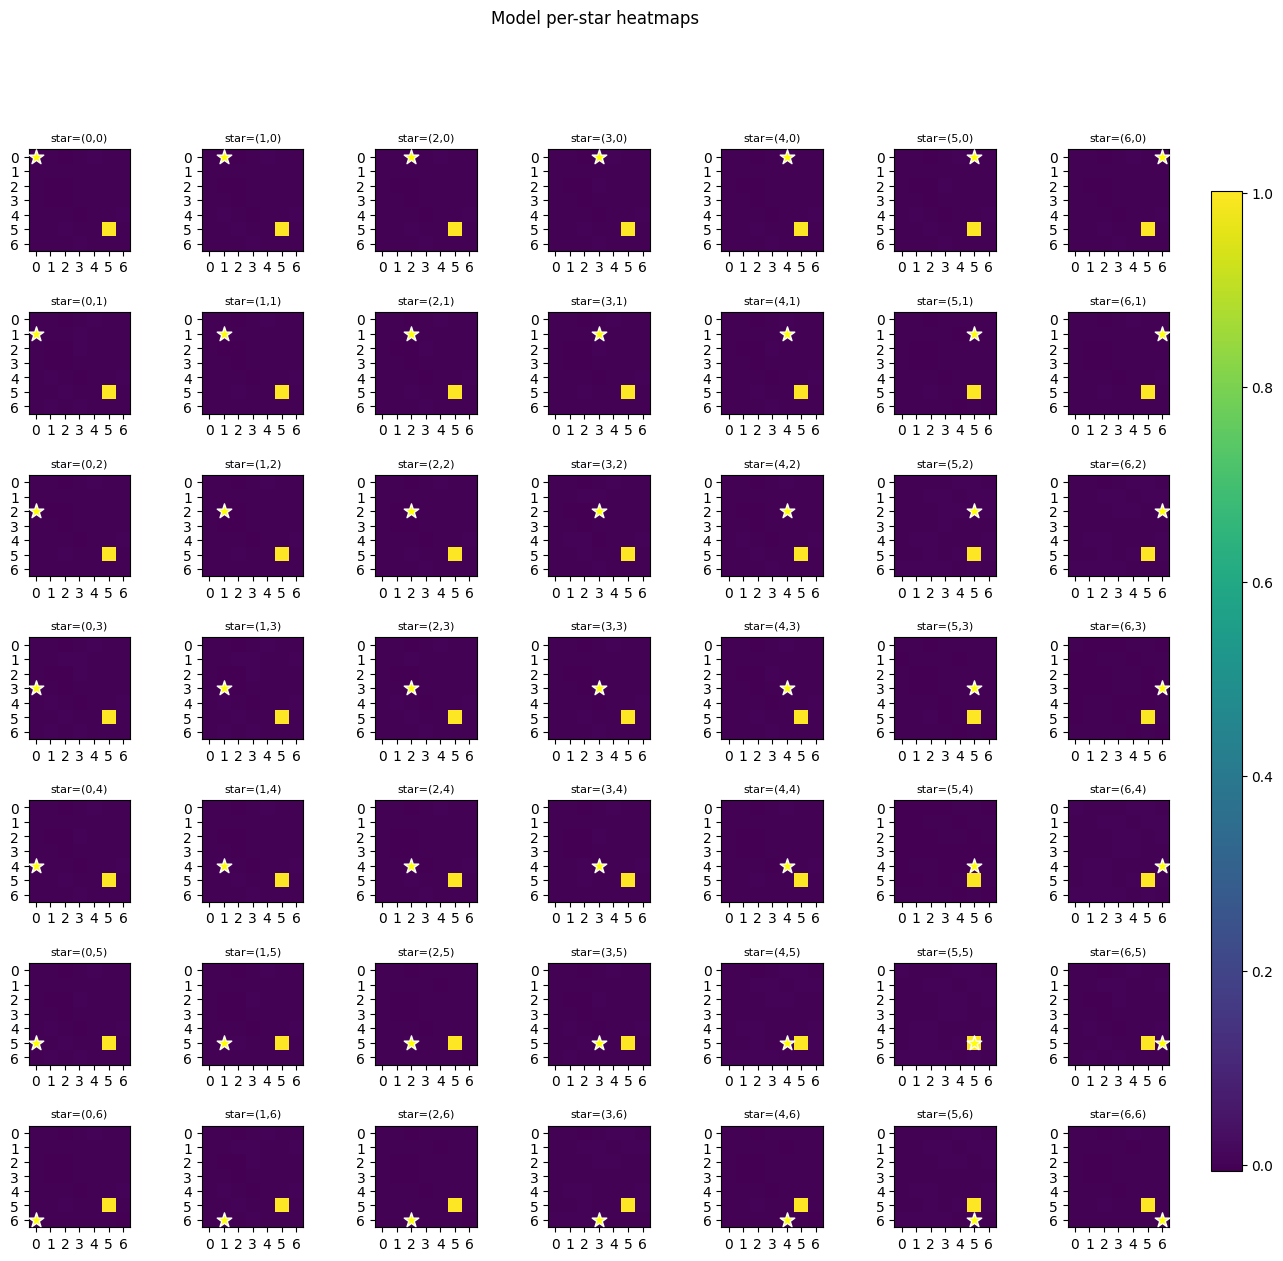

Computing triangular action heatmap for star=(5, 5) ...
preds_actions shape (rows, cols, actions): (7, 7, 4)


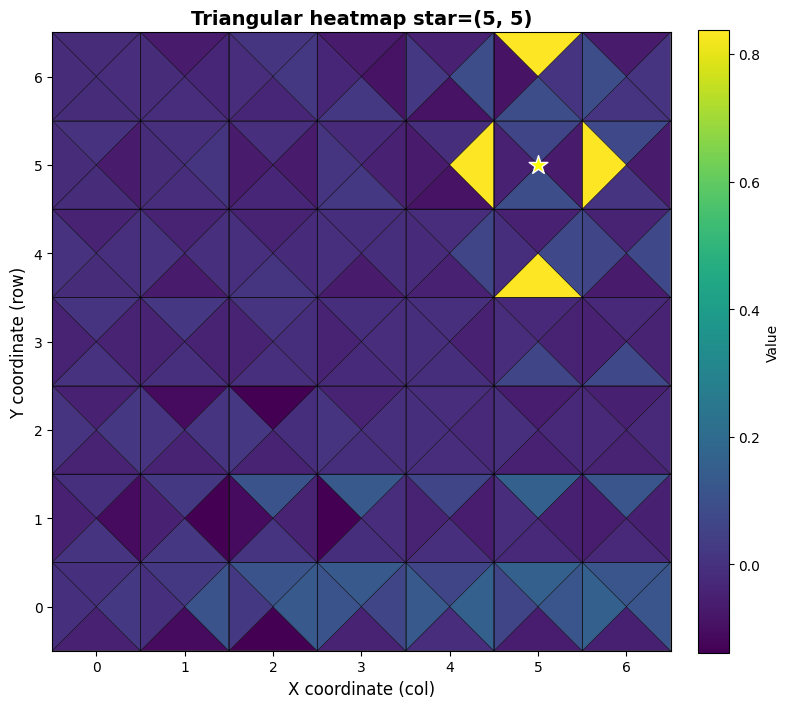


Numeric conv kernels (per-filter, per-channel):
Conv layer weight shape: (1, 3, 3, 3)
Format: (out_channels, in_channels, kernel_h, kernel_w)

=== Filter 0 ===
Channel 0:
[[-0.002  -0.0011  0.002 ]
 [-0.0009  0.0014 -0.0006]
 [ 0.0012  0.0005 -0.0007]]
Channel 1:
[[ 0.1201  0.5567  0.7788]
 [ 0.0571  0.0616  0.1787]
 [-0.2323 -0.2665 -0.7343]]
Channel 2:
[[-0.3997 -0.0593  0.0121]
 [ 0.1912 -0.0051  0.0846]
 [ 0.599   0.3044 -0.0902]]


Done. If the triangular up/down orientation is wrong, call the triangular plot with np.transpose(preds_actions,(1,0,2)).


In [ ]:
# --- Minimal visualization cell (uses only your existing helpers) ---
import numpy as np
import torch
import matplotlib.pyplot as plt

# @title CNN {"display-mode":"form"}


# Cleaned training script for gridworld -> scalar reward regression
# - Outputs a single scalar per image (regression)
# - Uses MSE loss
# - Keeps only essential dataset / model / training logic
# - Small hook `compute_full_domain_metric` where you can call STARC later

import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from typing import Tuple
from tqdm import trange

# ------------------------
# Config
# ------------------------
H = W = 7
CHANNELS = 3
STAR_POS = (5, 5)
AGENT_ALLOWED = list(range(1, 7))
N_POS = 2000
N_NEG = 2000
BATCH_SIZE = 64
EPOCHS = 200
LR = 5e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42
ALPHA = 0.0  # placeholder: weight for -alpha * STARC (0.0 means no STARC in loss)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ------------------------
# Simple image generator (kept from your original)
# ------------------------
def make_grid_image(agent_pos: Tuple[int,int], star_pos: Tuple[int,int] = STAR_POS):
    """
    Channel order: (R, G, B)
    R: star, G: agent, B: border
    Returns (img: np.float32 (3,H,W), reward: float scalar 0.0/1.0)
    """
    r_agent, c_agent = agent_pos
    img = np.zeros((CHANNELS, H, W), dtype=np.float32)

    # Border -> BLUE channel (index 2)
    img[2, 0, :] = 1.0
    img[2, -1, :] = 1.0
    img[2, :, 0] = 1.0
    img[2, :, -1] = 1.0

    # Star -> RED channel (index 0)
    r_star, c_star = star_pos
    img[0, r_star, c_star] = 1.0

    # Agent -> GREEN channel (index 1)
    img[1, r_agent, c_agent] = 1.0

    reward = 1.0 if (r_agent, c_agent) == (r_star, c_star) else 0.0
    return img, reward

# ------------------------
# Balanced dataset generator (returns numpy arrays)
# ------------------------
def generate_corner_dataset_aligned(n_pos=2000, n_neg=2000):
    X = []
    y = []
    grid_coords = [(r, c) for r in range(H) for c in range(W)]

    # Positive samples: Agent fixed at (5,5), star is random
    for _ in range(n_pos):
        random_star = random.choice(grid_coords)
        img, _ = make_grid_image(agent_pos=(5,5), star_pos=random_star)
        X.append(img)
        y.append(1.0)

    # Negative samples: Agent NOT at (5,5), star is random
    negative_agent_positions = [p for p in grid_coords if p != (5,5)]
    for _ in range(n_neg):
        random_agent = random.choice(negative_agent_positions)
        random_star = random.choice(grid_coords)
        img, _ = make_grid_image(agent_pos=random_agent, star_pos=random_star)
        X.append(img)
        y.append(0.0)

    X = np.stack(X).astype(np.float32)
    y = np.array(y, dtype=np.float32).reshape(-1, 1)
    perm = np.random.permutation(len(X))
    return X[perm], y[perm]

# ------------------------
# Dataset wrapper
# ------------------------
class GridDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        img = torch.from_numpy(self.X[idx])            # float32 (C,H,W)
        label = torch.from_numpy(self.y[idx]).float() # float32 (1,)
        return img, label

# ------------------------
# Tiny regression CNN (single scalar output)
# - simplified, fewer channels/parameters kept small for fast experiments
# ------------------------
class CNN(nn.Module):
    def __init__(self, in_channels=3, hidden_channels=1):
        super().__init__()
        # small conv stack
        self.conv1 = nn.Conv2d(in_channels, hidden_channels, kernel_size=3, padding=1)
        #self.conv2 = nn.Conv2d(hidden_channels, hidden_channels, kernel_size=3, padding=1)
        #self.pool = nn.AdaptiveAvgPool2d((3,3))
        flat = hidden_channels * 3 * 3
        #self.fc1 = nn.Linear(flat, 64)
        self.fc_out = nn.Linear(49, 1)  # single scalar output

        # optional: simple initialization
        nn.init.kaiming_normal_(self.conv1.weight, nonlinearity='relu')
        #nn.init.kaiming_normal_(self.conv2.weight, nonlinearity='relu')
        #nn.init.xavier_uniform_(self.fc1.weight)
        nn.init.xavier_uniform_(self.fc_out.weight)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        #x = F.relu(self.conv2(x))
        #x = self.pool(x)
        x = torch.flatten(x, 1)
        #x = F.relu(self.fc1(x))
        out = self.fc_out(x)  # raw scalar (no activation)
        return out

# ------------------------
# Hook for full-domain metric (STARC) integration
# - This is a placeholder: later, compute r_pred_full by forwarding
#   your enumerated full-domain images through `model` and pass to STARC.
# ------------------------
def compute_full_domain_metric(model, images_full_np, true_rewards_full_np):
    """
    images_full_np: np.ndarray (num_states, C, H, W)
    true_rewards_full_np: np.ndarray (num_states, 1)
    Returns a dict with metric placeholders. Replace STARC implementation here.
    """
    model.eval()
    with torch.no_grad():
        imgs = torch.from_numpy(images_full_np).to(DEVICE)
        preds = model(imgs).cpu().numpy()  # (num_states, 1)
    # Placeholder: compute a simple L2 between predicted and true full reward vectors
    l2 = float(np.mean((preds - true_rewards_full_np)**2))
    # Replace the following with STARC(preds, true_rewards_full_np) when available
    return {"full_l2": l2, "starc": None}

# ------------------------
# Training loop (MSE regression)
# ------------------------
def train_one_epoch(model, loader, opt, criterion):
    model.train()
    total_loss = 0.0
    total = 0
    for imgs, labels in loader:
        imgs = imgs.to(DEVICE)
        labels = labels.to(DEVICE)
        opt.zero_grad()
        out = model(imgs)          # (B,1)
        mse = criterion(out, labels)
        # if you include STARC inside gradient, add -ALPHA * starc_term here (requires starc differentiable)
        loss = mse
        loss.backward()
        opt.step()
        total_loss += loss.item() * imgs.size(0)
        total += imgs.size(0)
    return total_loss / total

def eval_model(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total = 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            labels = labels.to(DEVICE)
            out = model(imgs)
            loss = criterion(out, labels)
            total_loss += loss.item() * imgs.size(0)
            total += imgs.size(0)
    return total_loss / total

# ------------------------
# Main runner
# ------------------------
def main():
    # Generate dataset
    X, y = generate_corner_dataset_aligned()
    N = len(X)
    n_val = int(0.1 * N)
    n_train = N - n_val
    train_X, val_X = X[:n_train], X[n_train:]
    train_y, val_y = y[:n_train], y[n_train:]
    train_ds = GridDataset(train_X, train_y)
    val_ds = GridDataset(val_X, val_y)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

    model = CNN(in_channels=CHANNELS).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = nn.MSELoss()

    print(f"Training (regression) on {len(train_ds)} samples, validating on {len(val_ds)} samples, device={DEVICE}")
    for epoch in range(1, EPOCHS + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss = eval_model(model, val_loader, criterion)
        print(f"Epoch {epoch:02d}: train_mse={train_loss:.6f} | val_mse={val_loss:.6f}")

        # Example place to compute full-domain metric each epoch (if you have images_full / true_full)
        # if you saved images_full.npy and true_rewards_full.npy, load them and call compute_full_domain_metric(...)
        # metrics = compute_full_domain_metric(model, images_full_np, true_rewards_full_np)
        # print(f"  full_l2={metrics['full_l2']:.6f} starc={metrics['starc']}")

    # Save final model
    torch.save({'model_state_dict': model.state_dict()}, "tinycnn_reg.pth")
    print("Saved model to tinycnn_reg.pth")



    # 1) Build full-domain images (every (agent, star) pair)
    print("Rendering full-domain images (every (agent,star) pair)...")
    images_full, true_rewards_full, state_index_map = generate_full_enumeration_dataset()
    images_full = images_full.astype(np.float32)                    # (S, C, H, W)
    true_rewards_full = np.array(true_rewards_full).reshape(-1)     # (S,)

    # normalize state_index_map to array shape (S,2,2) if it was a list
    if isinstance(state_index_map, list):
        sidx = np.zeros((len(state_index_map), 2, 2), dtype=np.int32)
        for i, (agent, star) in enumerate(state_index_map):
            sidx[i, 0, 0], sidx[i, 0, 1] = int(agent[0]), int(agent[1])
            sidx[i, 1, 0], sidx[i, 1, 1] = int(star[0]), int(star[1])
        state_index_map = sidx

    S = images_full.shape[0]
    print(f"Full domain size S={S}, images shape={images_full.shape}")

    # 2) Forward the full domain through the model -> r_state (S,)
    model = model.to(DEVICE)
    model.eval()
    print("Forwarding full domain through model (batched)...")
    r_state = model_predict_full(model, images_full, device=DEVICE, batch_size=256)
    r_state = np.array(r_state).reshape(-1)
    print(f"r_state stats: min={r_state.min():.4f}, max={r_state.max():.4f}, mean={r_state.mean():.4f}")

    # 3) Build per-star agent heatmaps and plot grid (one panel per star)
    print("Building per-star heatmaps and plotting grid...")
    heatmaps, star_positions = build_agent_heatmaps_per_star(r_state, state_index_map, env)
    # Use your provided plotting function
    plot_star_heatmaps_grid(heatmaps, star_positions, env, title_prefix="Model per-star heatmaps", cmap="viridis", vmin=None, vmax=None)

    # 4) Triangular action heatmap for one example star (choose inner star if you want)
    example_star = (5, 5)   # (x,y) — change to any star you want to inspect
    print(f"Computing triangular action heatmap for star={example_star} ...")
    preds_actions = compute_preds_actions_from_model(model, env, example_star, DEVICE)   # expected (rows, cols, 4)
    print("preds_actions shape (rows, cols, actions):", preds_actions.shape)

    # The triangular plot in your notebook historically expects either (rows,cols,4) OR (cols,rows,4).
    # Try the direct call first; if triangles look flipped, swap with transpose=(1,0,2).
    try:
        plot_quadrant_action_heatmap(preds_actions, star_coords=example_star, title=f"Triangular heatmap star={example_star}")
    except Exception as e:
        print("Direct triangular plot failed; trying transpose (cols,rows,4). Error:", e)
        plot_quadrant_action_heatmap(np.transpose(preds_actions, (1,0,2)), star_coords=example_star, title=f"Triangular heatmap star={example_star} (transposed)")

    # 5) Print numeric conv kernels (per-filter, per-channel) — no colors, raw numbers
    print("\nNumeric conv kernels (per-filter, per-channel):")
    print_conv_weights(model)

    print("\nDone. If the triangular up/down orientation is wrong, call the triangular plot with np.transpose(preds_actions,(1,0,2)).")

if __name__ == "__main__":
  main()

Conv layer weight shape: (2, 3, 3, 3)
Format: (out_channels, in_channels, kernel_h, kernel_w)

=== Filter 0 ===
Channel 0:
[[-0.107   0.5455  0.1016]
 [ 0.3044  0.011   0.4843]
 [ 0.4638 -0.262  -0.4721]]
Channel 1:
[[ 0.1319 -0.0911 -0.075 ]
 [ 0.2321 -0.2024 -0.6414]
 [-0.0442  0.3295 -0.1554]]
Channel 2:
[[ 0.2474 -0.1648 -0.2041]
 [-0.3225 -0.0501  0.2389]
 [ 0.3546 -0.0882  0.0062]]

=== Filter 1 ===
Channel 0:
[[-0.2106 -0.6726 -0.1533]
 [-0.0067 -0.1144 -0.1214]
 [-0.2115  0.38    0.4892]]
Channel 1:
[[-0.3066  0.3182 -0.4036]
 [-0.3526  0.4444 -0.6183]
 [-0.4581 -0.1995 -0.2581]]
Channel 2:
[[-0.0311  0.6158 -0.1841]
 [ 0.0496  0.011   0.1087]
 [ 0.4392  0.0552  0.625 ]]

Conv layer weight shape: (2, 3, 3, 3)
Format: (out_channels, in_channels, kernel_h, kernel_w)

=== Filter 0 ===
Channel 0:
[[ 0.4351 -0.1804  0.1792]
 [-0.0463 -0.3791  0.1253]
 [ 0.3349 -0.099   0.0822]]
Channel 1:
[[-0.3778  0.4546 -0.2154]
 [ 0.0502  0.4135 -0.27  ]
 [ 0.3691  0.3718 -0.0143]]
Channel 2:
[[

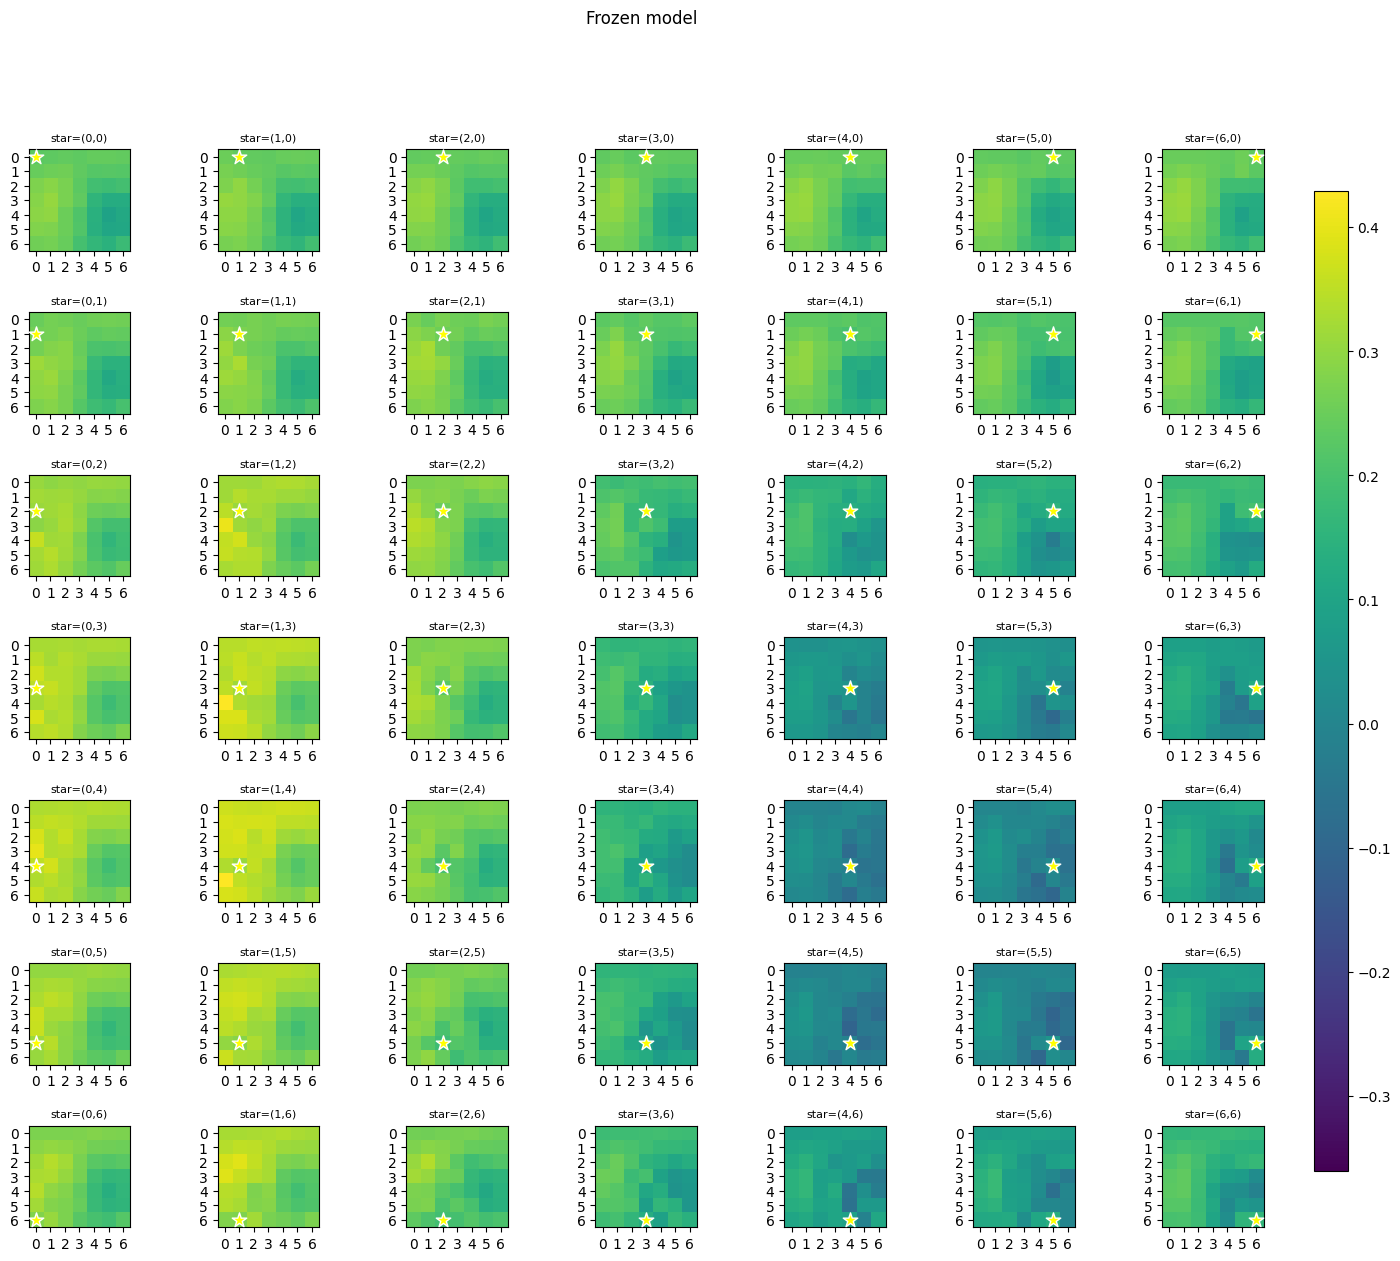

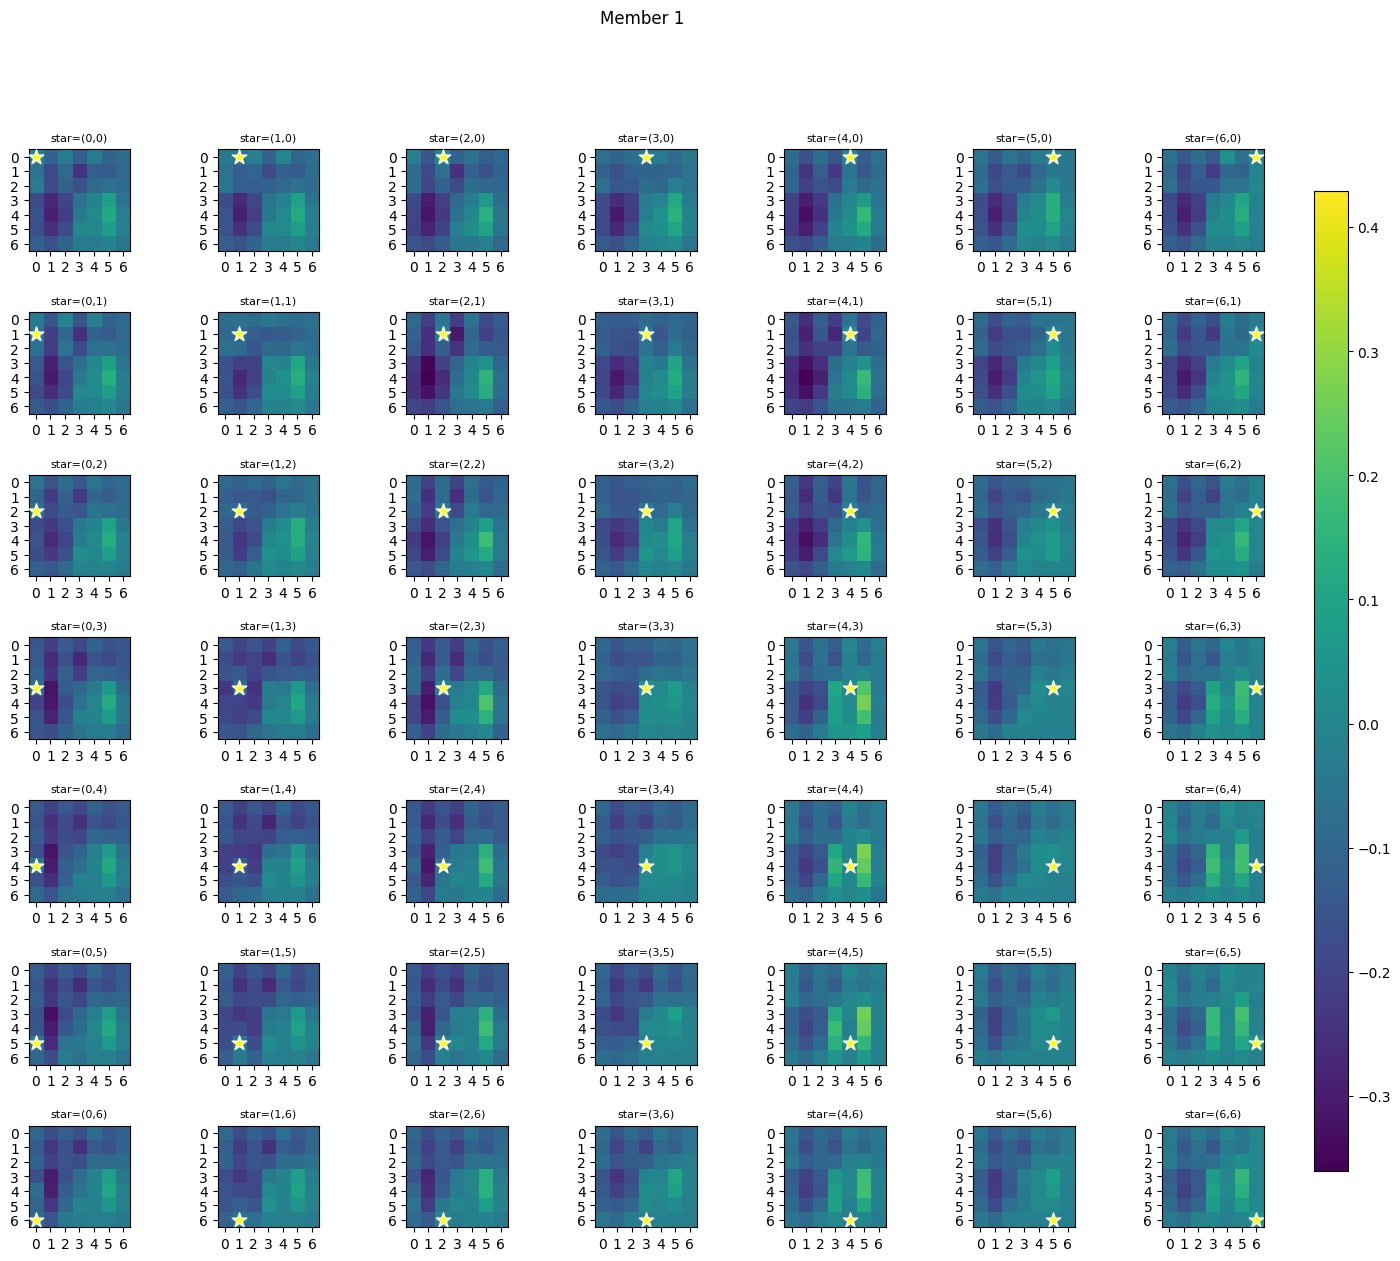

In [ ]:
# 1) Choose models and labels (None -> true reward)
models = [first_model] + list(ensemble_models)
labels = ["Frozen model"] + [f"Member {i+1}" for i in range(len(ensemble_models))]

assert len(models) == len(labels)

# -------------------------------------------------
# NEW: Print conv kernels for each model
# -------------------------------------------------
for m, label in zip(models, labels):
    if m is None:
        print(f"\n{label}: (true reward — no CNN weights)")
    else:
        print_conv_weights(m)

# -------------------------------------------------
# 2) Compute r_state (S,) for each model
# -------------------------------------------------
r_states = []
for m in models:
    if m is None:
        r_vec = np.array(true_rewards_full).reshape(-1)
    else:
        r_vec = model_predict_full(m, images_full, device=DEVICE, batch_size=256).reshape(-1)
    r_states.append(r_vec)

# -------------------------------------------------
# 3) Convert each r_state -> per-star agent heatmaps
# -------------------------------------------------
heatmaps_list = []
star_positions = None

for r_vec in r_states:
    heatmaps, star_positions_local = build_agent_heatmaps_per_star(r_vec, state_index_map, env)

    if star_positions is None:
        star_positions = star_positions_local
    else:
        assert star_positions == star_positions_local, "Star ordering mismatch!"

    heatmaps_list.append(heatmaps)

# -------------------------------------------------
# 4) Plot them (shared vmin/vmax)
# -------------------------------------------------
all_vals = np.concatenate([h.reshape(-1) for h in heatmaps_list])
vmin = float(np.nanmin(all_vals))
vmax = float(np.nanmax(all_vals))

for heatmaps, label in zip(heatmaps_list, labels):
    fig = plot_star_heatmaps_grid(
        heatmaps,
        star_positions,
        env,
        title_prefix=label,
        cmap='viridis',
        vmin=vmin,
        vmax=vmax,
        annotate=False,
        figsize_per_panel=(2.4, 2.0),
        save_path=None,
        star_marker_kwargs=None
    )